# 비는 도착지연을 늘리는가 — 첫 확인 (58편)

수집 시작 이후 처음으로 **비(`wx_ra`) 표본이 생겼다.** 이 프로젝트의 설계는
"기상이 지연을 설명한다"에 걸려 있으므로, 그 첫 조각을 검증한다.

> ⚠️ **이 노트북의 수치는 인용하면 안 된다.** 비 표본은 58편이고 그마저
> **이틀(09-15·09-18)에만** 몰려 있다. 사실상 "이틀"이 표본이다.
> 저시정(8km 미만)은 아직 **0편**이라 기상 서사의 본체는 검증되지 않았다.
> 저시정이 쌓인 뒤 **같은 코드를 다시 돌려** 비교하는 것이 이 노트북의 목적이다.

**해석은 각 절의 출력을 실행한 뒤에 적었다.**

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu

sys.path.insert(0, str(Path.cwd().parent))
from config import DATA_PROCESSED

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="AppleGothic")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# 대시보드와 같은 검증된 팔레트 (dataviz 지침). 맑음=파랑, 비=주황.
CLEAR, RAIN = "#2a78d6", "#eb6834"

d = pd.read_parquet(DATA_PROCESSED / "dataset.parquet")
d["date"] = d["sched_time"].dt.date
print(f"{len(d):,}편 · {d.sched_time.min():%Y-%m-%d} ~ {d.sched_time.max():%Y-%m-%d}")

1,753편 · 2026-09-07 ~ 2026-09-18


## 1. 표본 규모 — 그리고 `astype(bool)` 함정

비 편수를 세기 전에 **결측부터 분리한다.** 기상 매칭률이 100%가 아니라
`wx_ra` 에 결측이 남는데, `astype(bool)` 은 결측을 `True` 로 바꾼다.

In [2]:
n_na = int(d["wx_ra"].isna().sum())
print(f"wx_ra 결측 {n_na}편  (기상 미매칭)")
print(f"  astype(bool) 로 세면 : {int(d['wx_ra'].astype(bool).sum()):3}편  ← 결측이 비로 둔갑")
print(f"  == 1 로 세면        : {int((d['wx_ra'] == 1).sum()):3}편  ← 맞다")

d = d[d["wx_ra"].notna()]
rain = d["wx_ra"] == 1
print(f"\n분석 대상 {len(d):,}편 (결측 제외) · 비 {int(rain.sum())}편 ({rain.mean():.1%})")

wx_ra 결측 37편  (기상 미매칭)
  astype(bool) 로 세면 :  95편  ← 결측이 비로 둔갑
  == 1 로 세면        :  58편  ← 맞다

분석 대상 1,716편 (결측 제외) · 비 58편 (3.4%)


비는 **58편(3.4%)** 이다. 결측 37편을 `True` 로 세면 95편이 되어 표본이
64% 부풀고, 지연이 큰 편이 그 결측에 섞여 있으면 결론까지 바뀐다.
**기상 플래그는 언제나 `== 1` 로 센다.**

## 2. 비 온 날이 더 늦는가

중앙값·평균·분산·15분 이상 지연 비율을 함께 본다.
지연 분포는 0 근처에 몰려 있고 꼬리가 길어 평균만으로는 오해한다.

In [3]:
rows = []
for name, g in [("맑음", d[~rain]), ("비", d[rain])]:
    x = g["delay_minutes"]
    rows.append({"구분": name, "n": len(x), "중앙값": x.median(), "평균": x.mean(),
                 "표준편차": x.std(), "15분+지연(%)": (x > 15).mean() * 100})
print(pd.DataFrame(rows).to_string(index=False))

u, p = mannwhitneyu(d.loc[rain, "delay_minutes"], d.loc[~rain, "delay_minutes"])
print(f"\nMann-Whitney U={u:,.0f}  p={p:.3f}")

구분    n   중앙값    평균  표준편차  15분+지연(%)
맑음 1658 -9.00 -6.48 21.18       8.75
 비   58 -6.50 -1.86 45.28       8.62

Mann-Whitney U=49,620  p=0.678


**효과가 검출되지 않는다.** 중앙값 차이는 2.5분(-9.0 → -6.5)이고 `p=0.678` 로
우연과 구분되지 않는다. 15분 이상 지연 비율은 8.6% 대 8.7% 로 사실상 같다.

눈에 띄는 것은 **표준편차가 두 배(21.2 → 45.3)** 라는 점뿐이다. 다음 절에서 본다.

## 3. 분산 두 배의 정체 — 한 편이 만든 것

비 표본의 분위수와 상위 지연편을 본다.

In [4]:
for name, g in [("맑음", d[~rain]["delay_minutes"]), ("비", d[rain]["delay_minutes"])]:
    q = g.quantile([0.5, 0.75, 0.9, 0.95, 0.99])
    print(f"{name:3} 50%{q[0.5]:+7.1f} 75%{q[0.75]:+7.1f} 90%{q[0.9]:+7.1f} "
          f"95%{q[0.95]:+7.1f} 99%{q[0.99]:+7.1f}  최대{g.max():+7.1f}")

print("\n비 표본의 지연 상위 5편")
print(d[rain].nlargest(5, "delay_minutes")[
    ["sched_time", "flight_no", "origin", "delay_minutes"]].to_string(index=False))

worst = d[rain]["delay_minutes"].idxmax()
print(f"\n최대 지연편 제외 시 비 표본 표준편차: "
      f"{d[rain].drop(worst)['delay_minutes'].std():.1f}  (제외 전 {d[rain]['delay_minutes'].std():.1f})")

맑음  50%   -9.0 75%   +1.0 90%  +13.0 95%  +26.1 99%  +66.4  최대 +165.0
비   50%   -6.5 75%   -1.0 90%   +8.3 95%  +18.1 99% +152.9  최대 +325.0

비 표본의 지연 상위 5편
         sched_time flight_no origin  delay_minutes
2026-09-18 07:05:00     VN428    HAN         325.00
2026-09-18 07:00:00     LJ022    BKK          23.00
2026-09-18 11:35:00    KE1811    GMP          19.00
2026-09-15 15:30:00     BX125    KIX          18.00
2026-09-18 07:50:00     VN422    SGN          16.00

최대 지연편 제외 시 비 표본 표준편차: 12.0  (제외 전 45.3)


**분산 차이는 전부 한 편 때문이다.** 09-18 07:05 하노이발 `VN428` 이 +325분이고,
이 한 편을 빼면 비 표본의 표준편차는 **45.3 → 12.0** 으로 맑음(21.2)보다 오히려
**낮아진다.**

게다가 이 편은 하노이발이다. 5시간이 넘는 지연이 **김해의 비 때문일 가능성은 희박하다** —
도착 시각에 김해에 비가 왔다는 것뿐이다. 90·95 분위수를 보면 비 표본이 맑음보다
오히려 작다(+8.3 대 +13.0, +18.1 대 +26.1).

## 4. 날짜 안에서 비교하면 방향이 엇갈린다

비는 이틀에만 왔다. 날짜가 교란요인이므로 **같은 날 안에서** 비교한다.

In [5]:
rows = []
for day in sorted(d.loc[rain, "date"].unique()):
    g = d[d["date"] == day]
    a, b = g[g["wx_ra"] == 1]["delay_minutes"], g[g["wx_ra"] != 1]["delay_minutes"]
    rows.append({"날짜": day, "비 n": len(a), "비 중앙값": a.median(),
                 "맑음 n": len(b), "맑음 중앙값": b.median(), "차이": a.median() - b.median()})
print(pd.DataFrame(rows).to_string(index=False))

        날짜  비 n  비 중앙값  맑음 n  맑음 중앙값    차이
2026-09-15   11  -3.00   135   -8.00  5.00
2026-09-18   47  -9.00   109   -6.00 -3.00


**방향이 엇갈린다.** 09-15 는 비가 5분 더 늦고, 09-18 은 비가 3분 더 빠르다.
날씨가 아니라 그날의 다른 요인이 지배한다는 뜻이다.

표본이 이틀이므로 이 두 값은 "비의 효과"가 아니라 **"그 이틀의 차이"** 로 읽어야 한다.

## 5. 그림

두 분포를 같은 축에서 본다. 상자는 거의 겹치고 점 하나만 멀리 떨어져 있다 —
그것이 이 절의 전부다.

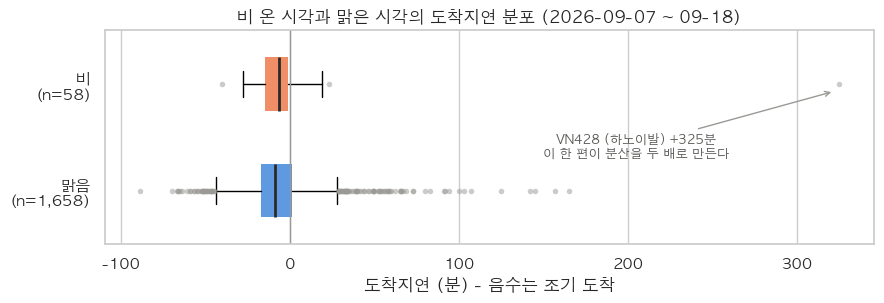

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.2))
groups = [d[~rain]["delay_minutes"], d[rain]["delay_minutes"]]
labels = [f"맑음\n(n={len(groups[0]):,})", f"비\n(n={len(groups[1])})"]

bp = ax.boxplot(groups, vert=False, tick_labels=labels, widths=0.5, patch_artist=True,
                flierprops={"marker": "o", "markersize": 4, "alpha": 0.5,
                            "markerfacecolor": "#9a9995", "markeredgecolor": "none"},
                medianprops={"color": "#2b2a28", "linewidth": 2})
for patch, color in zip(bp["boxes"], [CLEAR, RAIN]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
    patch.set_edgecolor("none")

# AppleGothic 에는 유니코드 마이너스가 없다. 문자열에는 ASCII 하이픈만 쓴다.
# 주석을 두 상자 사이의 빈 공간에 둔다. 위로 올리면 제목과 겹친다.
ax.annotate("VN428 (하노이발) +325분\n이 한 편이 분산을 두 배로 만든다",
            xy=(322, 1.93), xytext=(205, 1.42), fontsize=9, color="#52514e",
            ha="center", va="center",
            arrowprops={"arrowstyle": "->", "color": "#9a9995"})
ax.axvline(0, color="#9a9995", linewidth=1)
ax.set_xlabel("도착지연 (분) - 음수는 조기 도착")
ax.set_title("비 온 시각과 맑은 시각의 도착지연 분포 (2026-09-07 ~ 09-18)")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 결론

**비의 효과는 현재 표본에서 검출되지 않는다** (58편, p=0.678). 분산이 두 배로 보였던 것은
하노이발 한 편이 만든 착시이고, 그 편을 빼면 비 표본이 맑음보다 더 촘촘하다.

**이것은 "기상이 무의미하다"는 뜻이 아니다.** 세 가지 이유로 아직 판정 자체가 불가능하다.

1. **표본이 이틀이다.** 58편이 09-15·09-18 에만 몰려 있어 날짜 효과와 분리되지 않는다.
2. **강수 강도를 모른다.** RKPK 는 시간당 강수량을 보고하지 않아 `wx_ra` 는 유무만 말한다
   — 부슬비와 폭우가 같은 1 이다. → `notebooks/01_metar_eda.ipynb`
3. **지연을 일으키는 것은 비가 아니라 저시정일 것이다.** 그리고 저시정은 아직 0편이다.

과거 7년 기준 저시정은 88일 중 20.7일이고 9월 하순부터 나온다.
→ `notebooks/03_climate_feasibility.ipynb`

**다시 돌릴 시점:** 저시정 표본이 쌓인 뒤(11월 말 표본 확정 전후). 같은 코드를 그대로
실행하고 §2 의 표와 §5 의 그림을 이 버전과 비교하면, "표본이 늘자 무엇이 달라졌는가" 가
그대로 보고서 재료가 된다.